# Stage 5 — Обучение обоих вариантов

Тренируем `FlattenMLP` (A) и `FrameRNN` (B) на одних и тех же train/val/test сплитах и сравниваем. Единый тренировочный цикл, разный тип модели.

- AdamW + cosine LR
- Weighted CE (class_weights из stage3)
- Early stopping по val macro-F1
- Отдельный best checkpoint на вариант

In [6]:
# ============================================================
# 5.0 — Импорты и конфиг
# ============================================================
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import json, time
from pathlib import Path

SRC_DIR    = Path('../data2/frame_processed')
STAGE3_DIR = Path('../data2/frame_stage3')
STAGE4_DIR = Path('../data2/frame_stage4')
STAGE5_DIR = Path('../data2/frame_stage5'); STAGE5_DIR.mkdir(exist_ok=True)

cfg_src = json.load(open(SRC_DIR    / 'config.json'))
cfg     = json.load(open(STAGE3_DIR / 'config.json'))
train_cfg = json.load(open(STAGE4_DIR / 'train_config.json'))

L         = cfg['L']
DIM_RGB   = cfg['dim_rgb']
DIM_AUD   = cfg['dim_audio']
N_CLASSES = cfg['n_classes']
GENRES    = cfg['genres']
DEQ_S     = cfg_src['dequant_scale']
DEQ_B     = cfg_src['dequant_bias']
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(train_cfg['seed']); np.random.seed(train_cfg['seed'])
print('device:', DEVICE, ' L:', L, ' classes:', N_CLASSES)

device: cuda  L: 60  classes: 12


In [7]:
# ============================================================
# 5.1 — Повтор FrameDataset из stage3 (чтобы notebook был самодостаточным)
# ============================================================
X_rgb_q   = np.load(SRC_DIR / 'X_rgb.npy',   mmap_mode='r')
X_audio_q = np.load(SRC_DIR / 'X_audio.npy', mmap_mode='r')
lengths   = np.load(SRC_DIR / 'lengths.npy')
y         = np.load(SRC_DIR / 'y.npy')
idx_train = np.load(STAGE3_DIR / 'idx_train.npy')
idx_val   = np.load(STAGE3_DIR / 'idx_val.npy')
idx_test  = np.load(STAGE3_DIR / 'idx_test.npy')
# NpzFile нельзя шарить между DataLoader-воркерами (форки дерутся за zip-хэндл
# → BadZipFile 'Overlapped entries'). Грузим в обычные ndarray до форка.
with np.load(STAGE3_DIR / 'norm_stats.npz') as _f:
    norm = {k: _f[k].astype(np.float32) for k in _f.files}
class_w   = torch.load(STAGE3_DIR / 'class_weights.pt', weights_only=True).to(DEVICE)

class FrameDataset(Dataset):
    def __init__(self, indices, augment=False, drop_audio_p=0.0):
        self.indices = np.asarray(indices, dtype=np.int64)
        self.augment = augment
        self.drop_audio_p = drop_audio_p
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        idx = int(self.indices[i]); T = int(lengths[idx])
        rgb = np.asarray(X_rgb_q[idx],   dtype=np.float32) * DEQ_S + DEQ_B
        aud = np.asarray(X_audio_q[idx], dtype=np.float32) * DEQ_S + DEQ_B
        rgb[:T] = (rgb[:T] - norm['rgb_mean']) / norm['rgb_std']
        aud[:T] = (aud[:T] - norm['aud_mean']) / norm['aud_std']
        rgb[T:] = 0; aud[T:] = 0
        if self.drop_audio_p and np.random.rand() < self.drop_audio_p:
            aud[:] = 0.0
        if self.augment:
            rgb[:T] += np.random.randn(*rgb[:T].shape).astype(np.float32) * 0.02
            aud[:T] += np.random.randn(*aud[:T].shape).astype(np.float32) * 0.03
        return (torch.from_numpy(rgb), torch.from_numpy(aud),
                torch.tensor(T, dtype=torch.long),
                torch.tensor(int(y[idx]), dtype=torch.long))

BATCH = train_cfg['batch_size']
dl_kwargs = dict(batch_size=BATCH, num_workers=2, pin_memory=(DEVICE.type=='cuda'))
train_loader = DataLoader(FrameDataset(idx_train, augment=True, drop_audio_p=0.1),
                          shuffle=True, **dl_kwargs)
val_loader   = DataLoader(FrameDataset(idx_val),   shuffle=False, **dl_kwargs)
test_loader  = DataLoader(FrameDataset(idx_test),  shuffle=False, **dl_kwargs)
print(f'loaders: train={len(train_loader)} val={len(val_loader)} test={len(test_loader)}  batch={BATCH}')

loaders: train=14 val=3 test=3  batch=256


In [8]:
# ============================================================
# 5.2 — Копируем определения моделей (для самодостаточности)
# ============================================================
class FlattenMLP(nn.Module):
    def __init__(self, n_frames, dim_rgb, dim_aud, n_classes,
                 hidden=(1024, 512), dropout=0.4):
        super().__init__()
        self.n_frames = n_frames
        in_dim = n_frames * (dim_rgb + dim_aud)
        layers = []; prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                       nn.GELU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, rgb, aud, lengths=None):
        K = self.n_frames
        x = torch.cat([rgb[:, :K], aud[:, :K]], dim=-1).reshape(rgb.size(0), -1)
        return self.net(x)

class FrameRNN(nn.Module):
    def __init__(self, dim_rgb, dim_aud, n_classes,
                 proj_dim=256, rnn_hidden=256, rnn_layers=1,
                 bidirectional=True, dropout=0.3, cell='gru'):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(dim_rgb + dim_aud, proj_dim), nn.LayerNorm(proj_dim),
            nn.GELU(), nn.Dropout(dropout))
        RNN = {'gru': nn.GRU, 'lstm': nn.LSTM}[cell]
        self.rnn = RNN(proj_dim, rnn_hidden, num_layers=rnn_layers,
                       batch_first=True, bidirectional=bidirectional,
                       dropout=dropout if rnn_layers > 1 else 0.0)
        out_dim = rnn_hidden * (2 if bidirectional else 1)
        self.head = nn.Sequential(nn.LayerNorm(out_dim), nn.Dropout(dropout),
                                  nn.Linear(out_dim, n_classes))
        self.bi = bidirectional; self.cell = cell
    def forward(self, rgb, aud, lengths):
        x = self.proj(torch.cat([rgb, aud], dim=-1))
        lens_cpu = lengths.detach().cpu().clamp(min=1)
        packed = pack_padded_sequence(x, lens_cpu, batch_first=True, enforce_sorted=False)
        _, h = self.rnn(packed)
        if self.cell == 'lstm': h = h[0]
        h = torch.cat([h[-2], h[-1]], dim=-1) if self.bi else h[-1]
        return self.head(h)

def build(kind):
    if kind == 'flatten':
        return FlattenMLP(min(30, L), DIM_RGB, DIM_AUD, N_CLASSES,
                          hidden=(1024, 512), dropout=0.4)
    if kind == 'rnn':
        return FrameRNN(DIM_RGB, DIM_AUD, N_CLASSES,
                        proj_dim=256, rnn_hidden=256, bidirectional=True,
                        dropout=0.3, cell='gru')
    raise ValueError(kind)

In [9]:
# ============================================================
# 5.3 — Train / Eval функции
# ============================================================
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = n = correct = 0
    preds, trues = [], []
    for rgb, aud, lens, yt in loader:
        rgb = rgb.to(DEVICE, non_blocking=True)
        aud = aud.to(DEVICE, non_blocking=True)
        yt  = yt.to(DEVICE,  non_blocking=True)
        logits = model(rgb, aud, lens)
        loss = F.cross_entropy(logits, yt, weight=class_w,
                               label_smoothing=train_cfg['label_smooth'])
        pred = logits.argmax(-1)
        total_loss += loss.item() * yt.size(0)
        correct    += (pred == yt).sum().item()
        n          += yt.size(0)
        preds.append(pred.cpu().numpy()); trues.append(yt.cpu().numpy())
    preds = np.concatenate(preds); trues = np.concatenate(trues)
    f1 = f1_score(trues, preds, average='macro', zero_division=0)
    return total_loss/n, correct/n, f1, preds, trues


def train_one(kind, epochs=None, patience=8):
    epochs = epochs or train_cfg['epochs']
    model  = build(kind).to(DEVICE)
    nparams = sum(p.numel() for p in model.parameters())
    print(f'\n=== Training [{kind}] — {nparams/1e6:.2f}M params ===')

    opt    = torch.optim.AdamW(model.parameters(), lr=train_cfg['lr'],
                                weight_decay=train_cfg['wd'])
    sched  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    hist   = {'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[],'val_f1':[]}
    best_f1 = -1; stale = 0

    for ep in range(1, epochs+1):
        model.train()
        t0 = time.time(); t_loss = t_correct = t_n = 0
        for rgb, aud, lens, yt in train_loader:
            rgb = rgb.to(DEVICE, non_blocking=True)
            aud = aud.to(DEVICE, non_blocking=True)
            yt  = yt.to(DEVICE,  non_blocking=True)
            logits = model(rgb, aud, lens)
            loss = F.cross_entropy(logits, yt, weight=class_w,
                                   label_smoothing=train_cfg['label_smooth'])
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            t_loss    += loss.item() * yt.size(0)
            t_correct += (logits.argmax(-1) == yt).sum().item()
            t_n       += yt.size(0)
        sched.step()
        v_loss, v_acc, v_f1, *_ = evaluate(model, val_loader)
        hist['train_loss'].append(t_loss/t_n); hist['train_acc'].append(t_correct/t_n)
        hist['val_loss'].append(v_loss); hist['val_acc'].append(v_acc); hist['val_f1'].append(v_f1)
        dt = time.time() - t0
        print(f'  ep{ep:>3}  train_loss={t_loss/t_n:.4f} acc={t_correct/t_n:.3f} | '
              f'val_loss={v_loss:.4f} acc={v_acc:.3f} f1={v_f1:.3f}  ({dt:.1f}s)')
        if v_f1 > best_f1:
            best_f1 = v_f1; stale = 0
            torch.save(model.state_dict(), STAGE5_DIR / f'best_{kind}.pt')
        else:
            stale += 1
            if stale >= patience:
                print(f'  early stop @ ep{ep} (best val_f1={best_f1:.3f})')
                break
    return model, hist, best_f1

In [10]:
# ============================================================
# 5.4 — Прогон обоих вариантов
# ============================================================
results = {}
for kind in train_cfg['variants']:
    torch.manual_seed(train_cfg['seed']); np.random.seed(train_cfg['seed'])
    model, hist, best = train_one(kind)
    model.load_state_dict(torch.load(STAGE5_DIR / f'best_{kind}.pt', weights_only=True))
    t_loss, t_acc, t_f1, preds, trues = evaluate(model, test_loader)
    results[kind] = dict(history=hist, best_val_f1=best,
                         test_loss=t_loss, test_acc=t_acc, test_f1=t_f1,
                         preds=preds.tolist(), trues=trues.tolist())
    print(f'[{kind}]  test: loss={t_loss:.4f}  acc={t_acc:.3f}  macro-f1={t_f1:.3f}')


=== Training [flatten] — 35.92M params ===
  ep  1  train_loss=1.7589 acc=0.514 | val_loss=1.2544 acc=0.703 f1=0.699  (2.4s)
  ep  2  train_loss=0.6135 acc=0.975 | val_loss=1.0782 acc=0.725 f1=0.726  (2.4s)
  ep  3  train_loss=0.3659 acc=0.999 | val_loss=1.0875 acc=0.707 f1=0.710  (2.4s)
  ep  4  train_loss=0.3507 acc=1.000 | val_loss=1.1200 acc=0.704 f1=0.706  (2.4s)
  ep  5  train_loss=0.3450 acc=1.000 | val_loss=1.1428 acc=0.713 f1=0.716  (2.4s)
  ep  6  train_loss=0.3387 acc=1.000 | val_loss=1.1473 acc=0.710 f1=0.714  (2.4s)
  ep  7  train_loss=0.3368 acc=1.000 | val_loss=1.1436 acc=0.719 f1=0.720  (2.4s)
  ep  8  train_loss=0.3337 acc=1.000 | val_loss=1.1433 acc=0.721 f1=0.723  (2.4s)
  ep  9  train_loss=0.3316 acc=1.000 | val_loss=1.1398 acc=0.715 f1=0.716  (2.4s)
  ep 10  train_loss=0.3296 acc=1.000 | val_loss=1.1412 acc=0.715 f1=0.717  (2.4s)
  early stop @ ep10 (best val_f1=0.726)
[flatten]  test: loss=1.0751  acc=0.749  macro-f1=0.750

=== Training [rnn] — 1.09M params ===
 

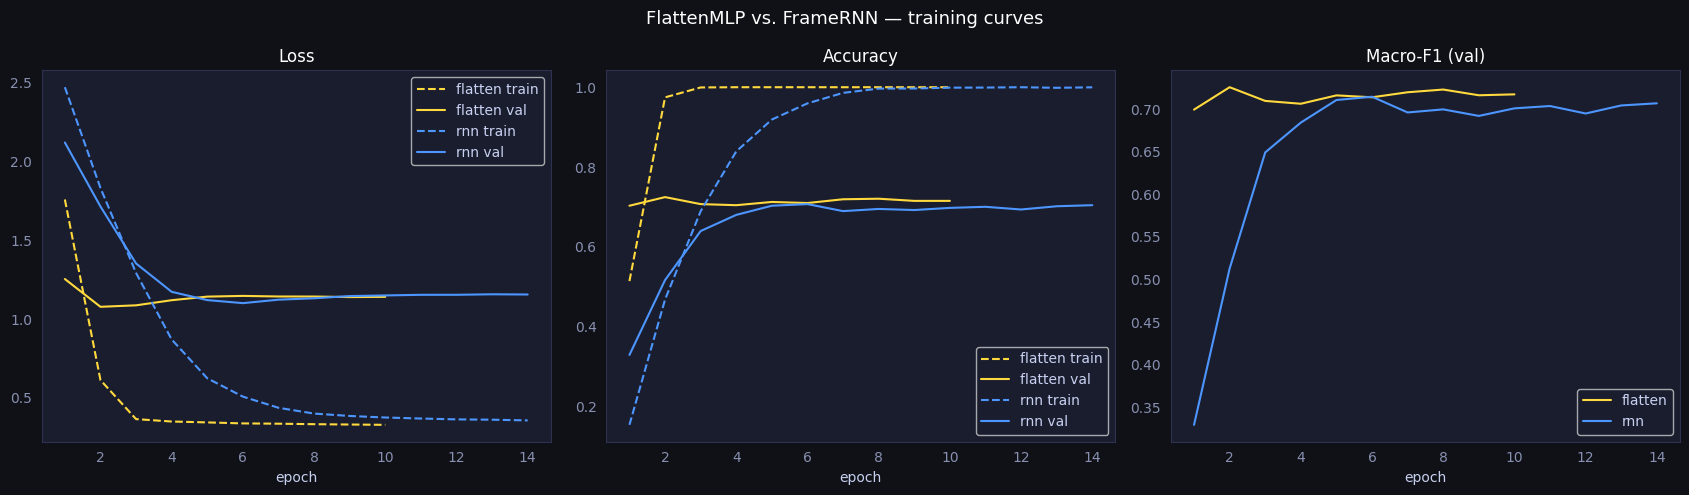


Итог на test:
  variant       acc  macro-f1
  flatten     0.749     0.750
  rnn         0.726     0.728


In [11]:
# ============================================================
# 5.5 — Сравнение кривых и метрик
# ============================================================
plt.rcParams.update({
    'figure.facecolor':'#0F1117','axes.facecolor':'#1A1D2E',
    'axes.edgecolor':'#2E3250','axes.labelcolor':'#C8D0F0',
    'axes.titlecolor':'#FFFFFF','xtick.color':'#8890B0','ytick.color':'#8890B0',
    'text.color':'#C8D0F0','grid.color':'#2E3250','grid.linestyle':'--','grid.alpha':0.4,
})
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('FlattenMLP vs. FrameRNN — training curves', fontsize=13, color='white')
colors = {'flatten':'#FFD93D', 'rnn':'#4D96FF'}
for kind in train_cfg['variants']:
    h = results[kind]['history']; e = range(1, len(h['train_loss'])+1); c = colors[kind]
    axes[0].plot(e, h['train_loss'], color=c, ls='--', label=f'{kind} train')
    axes[0].plot(e, h['val_loss'],   color=c, ls='-',  label=f'{kind} val')
    axes[1].plot(e, h['train_acc'],  color=c, ls='--', label=f'{kind} train')
    axes[1].plot(e, h['val_acc'],    color=c, ls='-',  label=f'{kind} val')
    axes[2].plot(e, h['val_f1'],     color=c, label=f'{kind}')
for ax, title in zip(axes, ('Loss', 'Accuracy', 'Macro-F1 (val)')):
    ax.set_title(title); ax.set_xlabel('epoch'); ax.grid(); ax.legend()
plt.tight_layout()
plt.savefig(STAGE5_DIR / 'training_curves.png', bbox_inches='tight', facecolor='#0F1117')
plt.show()

print('\nИтог на test:')
print(f'  {"variant":<10} {"acc":>6} {"macro-f1":>9}')
for kind in train_cfg['variants']:
    r = results[kind]
    print(f'  {kind:<10} {r["test_acc"]:>6.3f} {r["test_f1"]:>9.3f}')

best variant on test: flatten  (macro-f1 = 0.750)

              precision    recall  f1-score   support

     Animals       0.82      0.71      0.76        69
   Animation       0.80      0.88      0.84        69
      Beauty       0.75      0.91      0.82        23
       Dance       0.68      0.67      0.67        69
        Film       0.53      0.82      0.64        38
        Food       0.82      0.71      0.76        70
      Gaming       0.76      0.73      0.74        70
       Music       0.78      0.58      0.67        69
 Performance       0.68      0.77      0.72        70
      Sports       0.81      0.78      0.79        69
        Tech       0.81      0.84      0.82        56
    Vehicles       0.77      0.74      0.76        69

    accuracy                           0.75       741
   macro avg       0.75      0.76      0.75       741
weighted avg       0.76      0.75      0.75       741



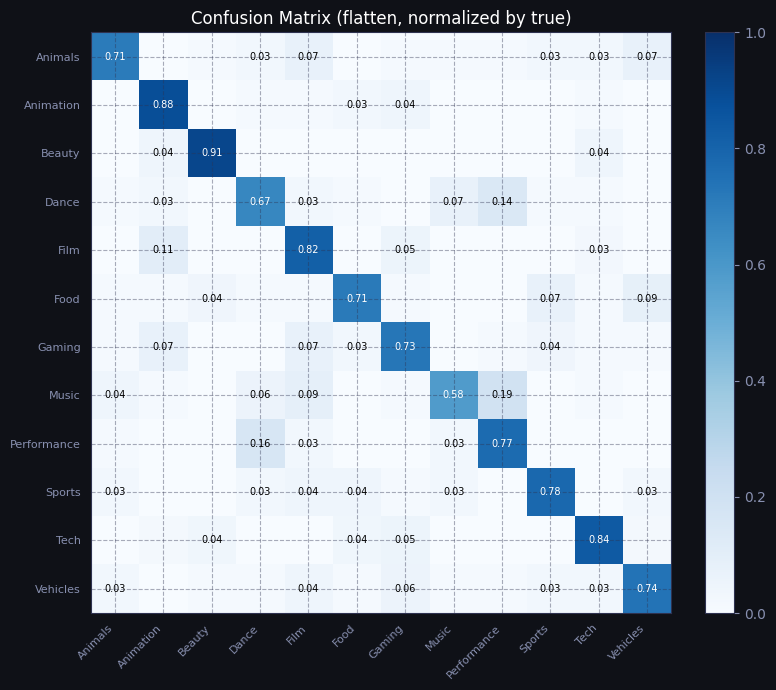


saved to ../data2/frame_stage5


In [12]:
# ============================================================
# 5.6 — Per-class отчёт и confusion matrix для лучшего
# ============================================================
best_kind = max(train_cfg['variants'], key=lambda k: results[k]['test_f1'])
print(f'best variant on test: {best_kind}  (macro-f1 = {results[best_kind]["test_f1"]:.3f})\n')

preds = np.array(results[best_kind]['preds'])
trues = np.array(results[best_kind]['trues'])
present = np.unique(trues)
print(classification_report(trues, preds, labels=present,
                             target_names=[GENRES[i] for i in present],
                             zero_division=0))

cm = confusion_matrix(trues, preds, labels=np.arange(N_CLASSES), normalize='true')
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(GENRES, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(GENRES, fontsize=8)
ax.set_title(f'Confusion Matrix ({best_kind}, normalized by true)')
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        v = cm[i, j]
        if v > 0.02:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    color='white' if v > 0.5 else 'black', fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(STAGE5_DIR / 'test_confusion_matrix.png', bbox_inches='tight', facecolor='#0F1117')
plt.show()

with open(STAGE5_DIR / 'results.json', 'w') as f:
    json.dump({k: {kk: vv for kk, vv in v.items() if kk != 'history'}
               | {'history': v['history']}
               for k, v in results.items()}, f, indent=2, default=float)
print('\nsaved to', STAGE5_DIR)